# Tugas Linear Regression dengan Python

**Topik:** Prediksi nilai ujian berdasarkan jam belajar mahasiswa  
**Kelompok:** -GALANG ADIKA RAMADHAN (24523275)      
              -MUHAMMAD FADLI (24523153)
              -MUHAMMAD FIKRI SALEH(24523227)

Kami menyusun notebook ini mengikuti urutan yang diminta pada instruksi tugas: mulai dari persiapan data, EDA, pembangunan model, evaluasi, visualisasi, lalu analisis hasil.

## 1) Persiapan Data

Agar temanya dekat dengan kehidupan sehari-hari mahasiswa, kami menggunakan dataset buatan sendiri dengan konteks:
- **Fitur (X):** `jam_belajar` per minggu
- **Target (y):** `nilai_ujian`

Catatan:
- Data dibuat dengan pola linear (semakin banyak jam belajar, nilai cenderung naik), ditambah sedikit variasi supaya lebih realistis.
- Total data: **60 mahasiswa**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [13]:
# Supaya hasil dataset tetap sama setiap kali dijalankan
np.random.seed(42)

# Membuat data jam belajar (antara 2 sampai 20 jam per minggu)
jam_belajar = np.random.uniform(2, 20, 60)

# Membuat target nilai ujian dengan pola linear + noise
# Rumus dasar: nilai = 35 + 3.2*(jam_belajar) + noise
noise = np.random.normal(0, 6, 60)
nilai_ujian = 35 + 3.2 * jam_belajar + noise

# Batasi rentang nilai agar tetap masuk akal (0-100)
nilai_ujian = np.clip(nilai_ujian, 0, 100)

# Susun ke DataFrame
df = pd.DataFrame({
    'jam_belajar': jam_belajar,
    'nilai_ujian': nilai_ujian
})

print('Jumlah data:', len(df))
print('Fitur      : jam_belajar')
print('Target     : nilai_ujian')

Jumlah data: 60
Fitur      : jam_belajar
Target     : nilai_ujian


## 2) Eksplorasi Data (EDA)

Di bagian ini kami cek dulu bentuk datanya, statistik ringkas, dan pola hubungan antara variabel X dan y.

In [14]:
# Melihat 5 data awal
df.head()

,jam_belajar,nilai_ujian
0,8.741722,54.102379
1,19.112858,91.842079
2,15.175891,80.799018
3,12.775853,82.225462
4,4.808336,52.448383


In [15]:
# Statistik deskriptif
df.describe()

,jam_belajar,nilai_ujian
count,60.000000,60.000000
mean,10.415014,67.769143
std,5.497745,17.637856
min,2.370521,38.004944
25%,5.320855,53.379346
50%,10.066002,65.277405
75%,14.852953,82.329319
max,19.458377,100.000000


In [16]:
# Cek apakah ada data kosong
df.isnull().sum()

,0
jam_belajar,0
nilai_ujian,0


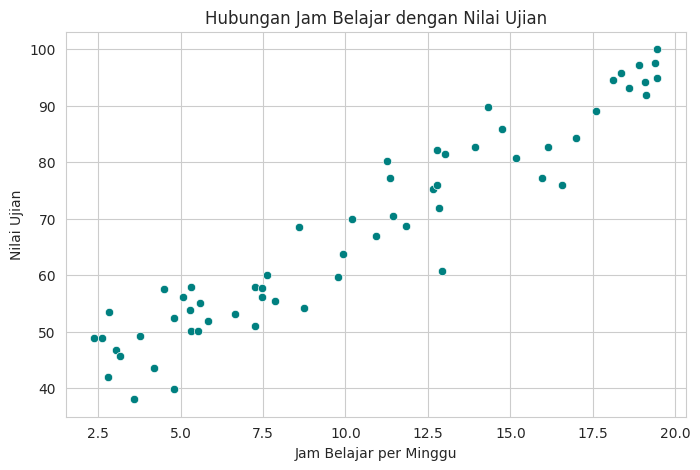

In [17]:
# Visualisasi hubungan jam belajar vs nilai ujian
plt.figure()
sns.scatterplot(data=df, x='jam_belajar', y='nilai_ujian', color='teal')
plt.title('Hubungan Jam Belajar dengan Nilai Ujian')
plt.xlabel('Jam Belajar per Minggu')
plt.ylabel('Nilai Ujian')
plt.show()

Dari scatter plot, titik data terlihat membentuk kecenderungan naik. Artinya, secara umum saat jam belajar meningkat, nilai ujian juga ikut meningkat. Ini cocok untuk dicoba dengan model regresi linear.

## 3) Pembangunan Model

Langkah yang dilakukan:
1. Pisahkan data train dan test (80:20).
2. Latih model `LinearRegression` dengan data training.

In [18]:
X = df[['jam_belajar']]
y = df['nilai_ujian']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print('Jumlah data train:', len(X_train))
print('Jumlah data test :', len(X_test))

Jumlah data train: 48
Jumlah data test : 12


## 4) Evaluasi Model

Pada tahap ini kami lakukan prediksi di data test, lalu hitung metrik evaluasi.
Metrik yang dipakai:
- `R² Score`
- `Mean Squared Error (MSE)`

In [19]:
# Prediksi pada data testing
y_pred = model.predict(X_test)

# Parameter model
slope = model.coef_[0]
intercept = model.intercept_

# Evaluasi
r2_train = model.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)

print(f'Slope (koefisien): {slope:.4f}')
print(f'Intercept        : {intercept:.4f}')
print(f'R^2 train score  : {r2_train:.4f}')
print(f'R^2 test score   : {r2_test:.4f}')
print(f'MSE test         : {mse_test:.4f}')

Slope (koefisien): 3.0098
Intercept        : 36.9726
R^2 train score  : 0.9061
R^2 test score   : 0.9224
MSE test         : 23.9113


## 5) Visualisasi Hasil

### 5.1 Garis regresi dan titik data aktual

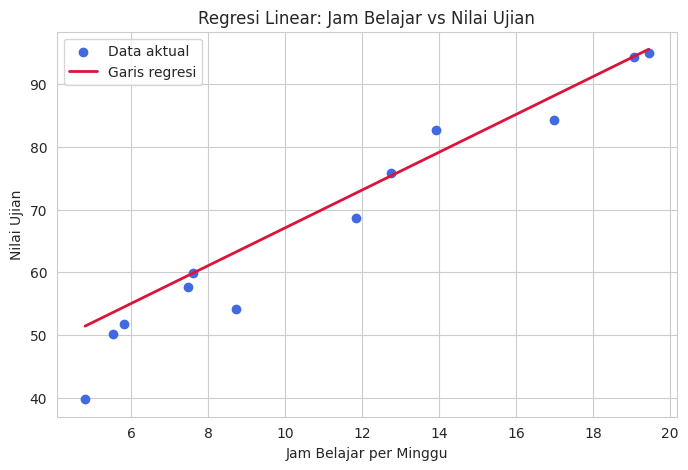

In [20]:
plt.figure()
plt.scatter(X_test, y_test, color='royalblue', label='Data aktual')

# Supaya garis regresi terlihat rapi dari kiri ke kanan
urutan = np.argsort(X_test['jam_belajar'].values)
x_sorted = X_test['jam_belajar'].values[urutan]
y_sorted = y_pred[urutan]

plt.plot(x_sorted, y_sorted, color='crimson', linewidth=2, label='Garis regresi')
plt.title('Regresi Linear: Jam Belajar vs Nilai Ujian')
plt.xlabel('Jam Belajar per Minggu')
plt.ylabel('Nilai Ujian')
plt.legend()
plt.show()

### 5.2 Perbandingan nilai aktual dan prediksi

In [21]:
hasil = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})
hasil.head(10)

,Aktual,Prediksi
0,54.102379,63.283282
1,39.807043,51.443341
2,57.627722,59.494947
3,82.640888,78.885023
4,51.775459,54.495869
5,75.869720,75.384040
6,94.261763,94.399057
7,68.678194,72.610784
8,84.313391,88.090639
9,50.164741,53.609752


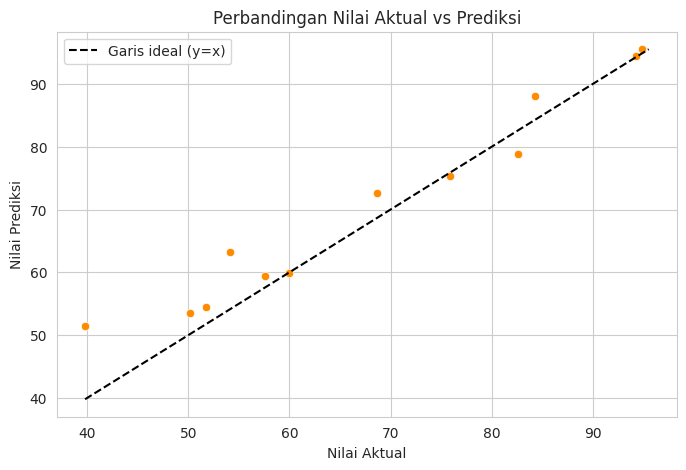

In [22]:
plt.figure()
sns.scatterplot(x=y_test, y=y_pred, color='darkorange')

# Garis ideal: jika prediksi sama persis dengan aktual
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--', label='Garis ideal (y=x)')

plt.title('Perbandingan Nilai Aktual vs Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.legend()
plt.show()

## 6) Analisis dan Kesimpulan

### Makna slope dan intercept
- **Slope** menunjukkan rata-rata kenaikan nilai ujian untuk setiap tambahan 1 jam belajar per minggu.
- **Intercept** menunjukkan perkiraan nilai saat jam belajar = 0.

### Kualitas prediksi model
- Kalau **R²** mendekati 1, berarti model cukup baik menjelaskan variasi data.
- **MSE** yang lebih kecil menandakan error prediksi yang lebih rendah.

### Indikasi overfitting atau underfitting
- Jika `R² train` dan `R² test` nilainya berdekatan, model biasanya cukup stabil.
- Jika `R² train` jauh lebih tinggi daripada `R² test`, bisa jadi model overfitting.
- Jika keduanya rendah, model kemungkinan underfitting (terlalu sederhana).

### Kesimpulan akhir
Untuk data ini, regresi linear sudah cukup masuk akal karena pola hubungan X dan y memang cenderung linear. Namun, dalam kasus nyata nilai ujian tentu tidak hanya dipengaruhi jam belajar saja; faktor lain seperti kualitas belajar, kehadiran kelas, atau tingkat kesulitan materi juga bisa berpengaruh.